# Quantization ahead of time.

#### Using python we can easily** calculate quantized values for our Model and Images

In [2]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
from tiny_imagenet import TinyImagenetDataset
import matplotlib.pyplot as plt
from pathlib import Path


# model_path = os.path.abspath(""/home/<NETID>/path/to/your/lab1/CNN_TinyImageNet.h5)" # Uncomment this to use a non-relative path
model_path = os.path.abspath("CNN_TinyImageNet.h5")
model = tf.keras.models.load_model(model_path)

### build image datasets ###
tiny_imagenet_builder = TinyImagenetDataset()
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

ds = tiny_imagenet_builder.as_dataset()
ds_train, ds_val = ds["train"], ds["validation"]
assert(isinstance(ds_train, tf.data.Dataset))
assert(isinstance(ds_val, tf.data.Dataset))
ds_train = ds_train.shuffle(1000).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.shuffle(1000).prefetch(tf.data.AUTOTUNE)

# We need to read the "human readable" labels so we can translate with the numeric values
# Read the labels file (words.txt)
with open(os.path.abspath('wnids.txt'), 'r') as f:
    wnids = [x.strip() for x in f]

# Map wnids to integer labels
wnid_to_label = {wnid: i for i, wnid in enumerate(wnids)}
label_to_wnid = {v: k for k, v in wnid_to_label.items()}

# Use words.txt to get names for each class
with open(os.path.abspath('words.txt'), 'r') as f:
    wnid_to_words = dict(line.split('\t') for line in f)
    for wnid, words in wnid_to_words.items():
        wnid_to_words[wnid] = [w.strip() for w in words.split(',')]

class_names = [str(wnid_to_words[wnid]) for wnid in wnids]

train_data = ds_train.take(1000).batch(1)
val_data = ds_val.take(1000).batch(1)

# build training dataset
train_imgs = []
for index, img_data in enumerate(train_data):
  train_imgs.append(img_data)

# build validation dataset
val_imgs = []
for index, img_data in enumerate(val_data):
  val_imgs.append(img_data)



2025-10-13 13:03:26.986385: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-13 13:03:27.973273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-13 13:03:28.413522: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-13 13:03:28.416662: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-13 13:03:29.149089: I tensorflow/core/platform/cpu_feature_gua

### Now we can take 1000 images and output the non-quantized versions for the training and validation

In [3]:
# Output non-quantized values to bin files
# Make a directory for our image data
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

# Create subdirectories
for subdir in ['Unquant_training', 'Unquant_validation']:
    subdir_path = os.path.join(img_dir, subdir)
    if not os.path.exists(subdir_path):
        Path(subdir_path).mkdir()

# Training dataset unquantized binary and metadata

with open(os.path.join(img_dir + "/Unquant_training", 'metadata.txt'), 'w') as metadata_file:
    metadata_file.write('Number\t\tDims\t\tClass Data\n')

for index, img_data in enumerate(train_imgs):
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    
    # --- KEY CHANGE HERE ---
    # 1. Cast the uint8 image tensor to float32
    # 2. Normalize the values from [0, 255] to [0.0, 1.0]
    image_float32 = tf.cast(image, tf.float32) / 255.0
    
    # 3. Flatten the float32 numpy array to be saved
    img_flat = image_float32.numpy().flatten()

    with open(os.path.join(img_dir + "/Unquant_training", f'image_{index}.bin'), 'wb') as img_file:
        img_flat.tofile(img_file)

    with open(os.path.join(img_dir + "/Unquant_training", 'metadata.txt'), 'a') as metadata_file:
        metadata_file.write(f'{index}\t\t{image.shape}\t\t{label_name}\n')

# --- APPLY THE SAME FIX to your validation data loop ---

with open(os.path.join(img_dir + "/Unquant_validation", 'metadata.txt'), 'w') as metadata_file:
    metadata_file.write('Number\t\tDims\t\tClass Data\n')

for index, img_data in enumerate(val_imgs):
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    
    # --- KEY CHANGE HERE ---
    image_float32 = tf.cast(image, tf.float32) / 255.0
    img_flat = image_float32.numpy().flatten()

    with open(os.path.join(img_dir + "/Unquant_validation", f'image_{index}.bin'), 'wb') as img_file:
        img_flat.tofile(img_file)

    with open(os.path.join(img_dir + "/Unquant_validation", 'metadata.txt'), 'a') as metadata_file:
        metadata_file.write(f'{index}\t\t{image.shape}\t\t{label_name}\n')





### Quantize all images, then output to binary

In [4]:
# quantization algorithm/math for the training images

# math is basically (maxInt) / (max(|Ix - avg(Ix)|)) <-- max across the 1000 images

maxInt = 127.0

layer_outputs = [layer.output for layer in model.layers]
layer_inputs = [layer.input for layer in model.layers]
feature_map_model = tf.keras.Model(inputs=model.inputs, outputs=layer_outputs)

#first get average across 1k images

def output_activations_to_bin(layer_name, quant_activations):
    with open(os.path.join(img_dir + "/image_activations", f'{layer_name}_output.bin'), 'wb') as act_file:
        quant_activations.tofile(act_file)

def quantize_activations(activations, scale, zero_point):
    """Quantizes a numpy array of activations."""
    quant_activations = np.round(activations * scale) + zero_point
    # Clamp the values to the int8 range [-128, 127]
    quant_activations = np.clip(quant_activations, -128, 127)
    return quant_activations.astype(np.int8)

def get_average(images):
    total_sum = 0.0
    total_count = 0
    for img_data in images:
        image = img_data["image"]
        
        # 1. Cast to float and NORMALIZE the image first
        normalized_image = tf.cast(image, tf.float32) / 255.0
        
        # 2. Perform calculations on the normalized data
        total_sum += tf.reduce_sum(normalized_image).numpy()
        total_count += tf.size(normalized_image).numpy()
    avg = total_sum / total_count
    return avg

def compute_max(images, avg):
    max_val = 0.0
    for img_data in images:
        image = img_data["image"]
        
        # 1. Cast to float and NORMALIZE the image first
        normalized_image = tf.cast(image, tf.float32) / 255.0
        
        # 2. Calculate deviation from the normalized average
        image_deviation = tf.cast(normalized_image - avg, tf.float32)
        img_max = tf.reduce_max(tf.abs(image_deviation)).numpy()
        if max_val < img_max:
            max_val = img_max
    return max_val

def quantize_images(images, scale, zero_point):
    quantized_images = []
    for img_data in images:
        image = img_data["image"]
        
        # 1. Cast to float and NORMALIZE the image first
        normalized_image = tf.cast(image, tf.float32) / 255.0
        
        # 2. Now apply the quantization math to the normalized data
        quant_image = np.round(normalized_image * scale) + zero_point
        
        quant_image = tf.cast(quant_image, tf.int8)
        quantized_images.append(quant_image)
    return quantized_images

def get_average_input(activations):
    total_sum = 0.0
    total_count = 0
    for act in activations:
        total_sum += tf.reduce_sum(act).numpy()
        total_count += tf.size(act).numpy()
    avg = total_sum / total_count
    return avg

def get_max_input(activations, avg):
    max_val = 0.0
    for act in activations:
        act = tf.cast(act - avg, tf.float32)
        act_max = tf.reduce_max(tf.abs(act)).numpy()
        if max_val < act_max:
            max_val = act_max
    return max_val


avg_ix = get_average(train_data)
max_val = compute_max(train_data, avg_ix)

print(f"Global Average for TrainingData: {avg_ix}")
print(f"Global Max for TrainingData: {max_val}")


# Get global train scale
train_scale = maxInt / (max_val) #maybe issue with div/0 but idc rn
zero_point = (-1 * round(avg_ix * train_scale)) # rounding issue potentially a problem?

print(f"Imgae Train Scale: {train_scale}, Zero Point: {zero_point}")





# now we can quantize all of them and print them out
quant_images = quantize_images(train_data, train_scale, zero_point)

# quantize the validation files (use same scale and zero_point, might not be perfect but its fine for our case)
quant_val = quantize_images(val_data, train_scale, zero_point)

# Create subdirectories
for subdir in ['quant_training', 'quant_val']:
    subdir_path = os.path.join(img_dir, subdir)
    if not os.path.exists(subdir_path):
        Path(subdir_path).mkdir()

# output to binary files

with open(os.path.join(img_dir + "/quant_training", 'metadata.txt'), 'w') as metadata_file:
    metadata_file.write('Number\t\tDims\t\tClass Data\n')

i = 0

for img_data in train_data:

    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    img_flat = quant_images[i].numpy().flatten()

    # print index, shape and flattened length
    #print(f"Image {index} shape: {image.shape}, flattened length: {len(img_flat)}")

    # 'wb' is write as a binary file
    with open(os.path.join(img_dir + "/quant_training", f'image_{i}.bin'), 'wb') as img_file:
        img_flat.tofile(img_file)

    # 'a' mode in python is appending
    with open(os.path.join(img_dir + "/quant_training", 'metadata.txt'), 'a') as metadata_file:
        metadata_file.write(f'{i}\t\t{image.shape}\t\t{label_name}\n')
    i += 1


with open(os.path.join(img_dir + "/quant_val", 'metadata.txt'), 'w') as metadata_file:
    metadata_file.write('Number\t\tDims\t\tClass Data\n')

i = 0

for img_data in val_data:

    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    img_flat = quant_val[i].numpy().flatten()

    # print index, shape and flattened length
    #print(f"Image {index} shape: {image.shape}, flattened length: {len(img_flat)}")

    # 'wb' is write as a binary file
    with open(os.path.join(img_dir + "/quant_val", f'image_{i}.bin'), 'wb') as img_file:
        img_flat.tofile(img_file) 

    # 'a' mode in python is appending
    with open(os.path.join(img_dir + "/quant_val", 'metadata.txt'), 'a') as metadata_file:
        metadata_file.write(f'{i}\t\t{image.shape}\t\t{label_name}\n')
    i += 1

# Get all layer activations
for batch in ds_val.batch(1000).take(1):
    all_activations = feature_map_model.predict(tf.cast(batch["image"], tf.float32) / 255.0)

# Get scales and zero points for each layer


for i, layer_name in enumerate([layer.name for layer in model.layers if 'conv' in layer.name or 'dense' in layer.name]):
    layer = model.get_layer(name=layer_name)
    
    # This is the activation for the ENTIRE BATCH (e.g., shape: 1000, 60, 60, 32)
    layer_activation = all_activations[i] 

    # --- Calculate Quantization Parameters (using the whole batch) ---
    min_val = np.min(layer_activation)
    max_val = np.max(layer_activation)
    
    if max_val == min_val:
        scale = 0.0
        zero_point = 0
    else:
        avg_ix = get_average_input(layer_activation)
        max_ix_avgIx = get_max_input(layer_activation, avg_ix)
        scale = 127.0 / max_ix_avgIx
        zero_point = -1 * round(avg_ix * scale)

    # --- Quantize and Save Activations for a SINGLE IMAGE ---
    
    # 1. Select activations for the FIRST image of the batch
    single_image_activations = layer_activation[0]

    # 2. Quantize these activations
    quantized_output = quantize_activations(single_image_activations, scale, zero_point)

    # 3. Save the quantized (int8) flattened output
    output_activations_to_bin(layer_name, quantized_output.flatten())
    print(f"qiantization activation: {layer_name} : scale {scale}, zero_point {zero_point}: {quantized_output.flatten()[:10]}")

    #print one quantized output and non-quantized output
    print(f"Non-Quantized Output for layer {layer_name} (first 10 values): {single_image_activations.flatten()[:10]}")
    print(f"Quantized Output for layer {layer_name} (first 10 values): {quantized_output.flatten()[:10]}")  

    # (Your print statements for debugging)
    print(f"\n> Layer: '{layer_name}'")
    print(f"  - Min Activation: {min_val:.6f}")
    print(f"  - Max Activation: {max_val:.6f}")
    print(f"  - Scale:          {scale:.6f}")
    print(f"  - Zero Point:     {zero_point}")

2025-10-13 13:03:45.739043: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-10-13 13:03:45.740167: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-13 13:03:46.019907: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

Global Average for TrainingData: 0.4475956327617168
Global Max for TrainingData: 0.5524044036865234
Imgae Train Scale: 229.90403253930162, Zero Point: -103


2025-10-13 13:03:46.323941: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-10-13 13:03:46.325327: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-10-13 13:03:46.585947: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step


2025-10-13 13:03:56.514628: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


qiantization activation: conv2d : scale 76.89625853752686, zero_point -3: [-3 -3 -3  1 -3 -3 -3 -3 -3 -3]
Non-Quantized Output for layer conv2d (first 10 values): [0.         0.         0.         0.05845724 0.         0.
 0.         0.         0.         0.        ]
Quantized Output for layer conv2d (first 10 values): [-3 -3 -3  1 -3 -3 -3 -3 -3 -3]

> Layer: 'conv2d'
  - Min Activation: 0.000000
  - Max Activation: 1.684554
  - Scale:          76.896259
  - Zero Point:     -3
qiantization activation: conv2d_1 : scale 31.139472262438417, zero_point -1: [-1 -1  0 -1 -1 14 -1 -1 -1 -1]
Non-Quantized Output for layer conv2d_1 (first 10 values): [0.         0.         0.01763256 0.         0.         0.47108424
 0.         0.         0.         0.        ]
Quantized Output for layer conv2d_1 (first 10 values): [-1 -1  0 -1 -1 14 -1 -1 -1 -1]

> Layer: 'conv2d_1'
  - Min Activation: 0.000000
  - Max Activation: 4.109264
  - Scale:          31.139472
  - Zero Point:     -1
qiantization acti

# Now We can do Weights

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,218 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Max Weight: 0.6923781633377075
Min Weight: -0.6923781633377075
Overall Weight Scale: 183.42577326208328
Overall Bias Scale: 42170.324944592554
Max Weight: 0.30287936329841614
Min Weight: -0.30287936329841614
Weight Scale for conv2d: 419.3088582098988
Bias Scale for conv2d: 96400.79738190598
Quantized weights for conv2d, shape: (5, 5, 3, 32)
Quantized biases for conv2d, shape: (32,)


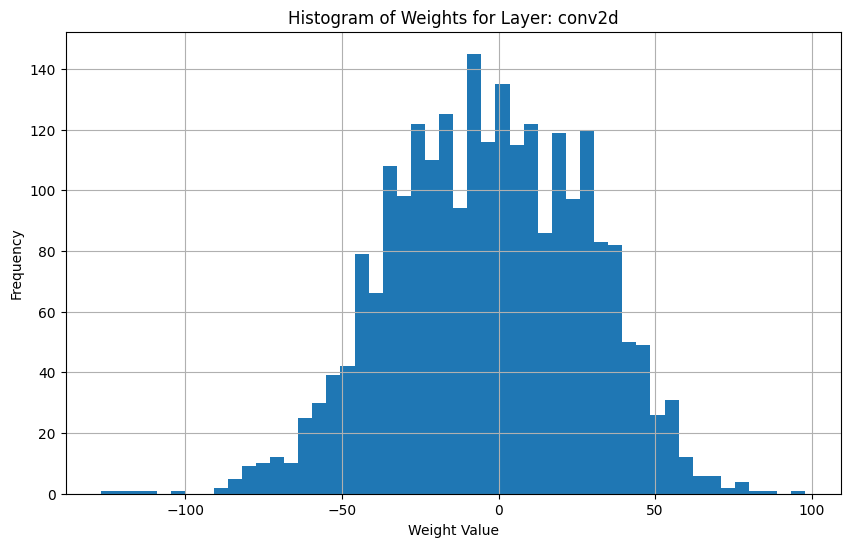

Max Weight: 0.48677802085876465
Min Weight: -0.48677802085876465
Weight Scale for conv2d_1: 260.8992077660963
Bias Scale for conv2d_1: 59981.77995173462
Quantized weights for conv2d_1, shape: (5, 5, 32, 32)
Quantized biases for conv2d_1, shape: (32,)


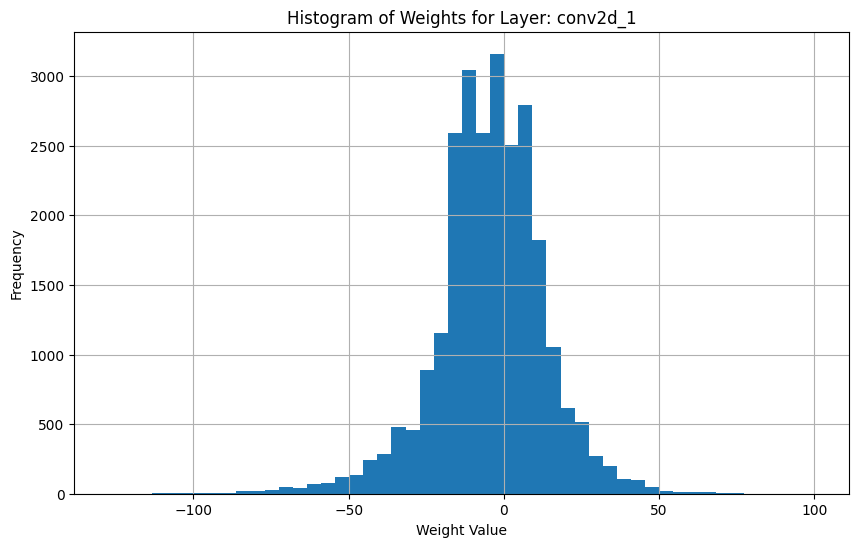

Max Weight: 0.6923781633377075
Min Weight: -0.6923781633377075
Weight Scale for conv2d_2: 183.42577326208328
Bias Scale for conv2d_2: 42170.324944592554
Quantized weights for conv2d_2, shape: (3, 3, 32, 64)
Quantized biases for conv2d_2, shape: (64,)


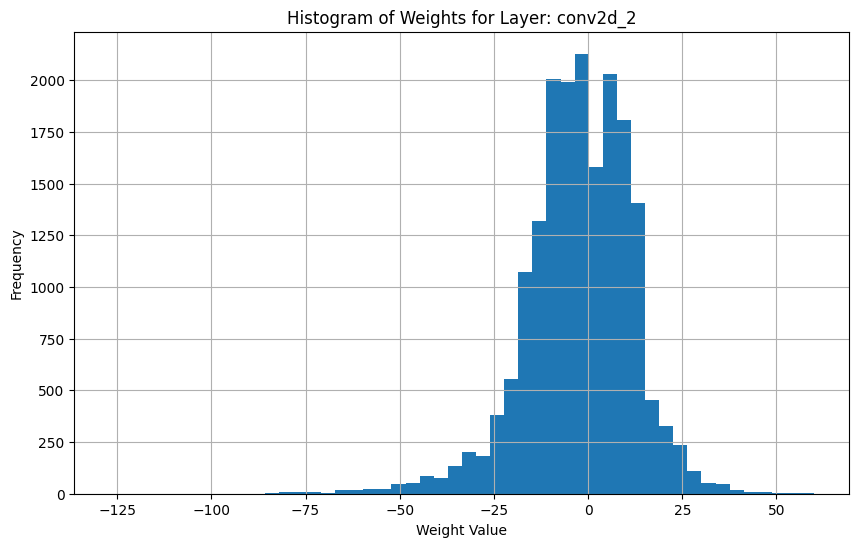

Max Weight: 0.5415472388267517
Min Weight: -0.5415472388267517
Weight Scale for conv2d_3: 234.51324444962967
Bias Scale for conv2d_3: 53915.54058284486
Quantized weights for conv2d_3, shape: (3, 3, 64, 64)
Quantized biases for conv2d_3, shape: (64,)


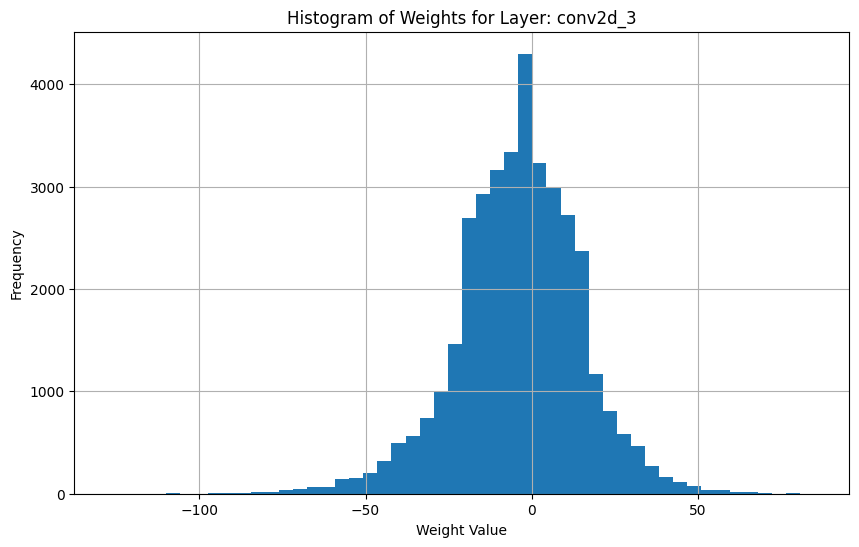

Max Weight: 0.5366791486740112
Min Weight: -0.5366791486740112
Weight Scale for conv2d_4: 236.64045885476003
Bias Scale for conv2d_4: 54404.59575266002
Quantized weights for conv2d_4, shape: (3, 3, 64, 64)
Quantized biases for conv2d_4, shape: (64,)


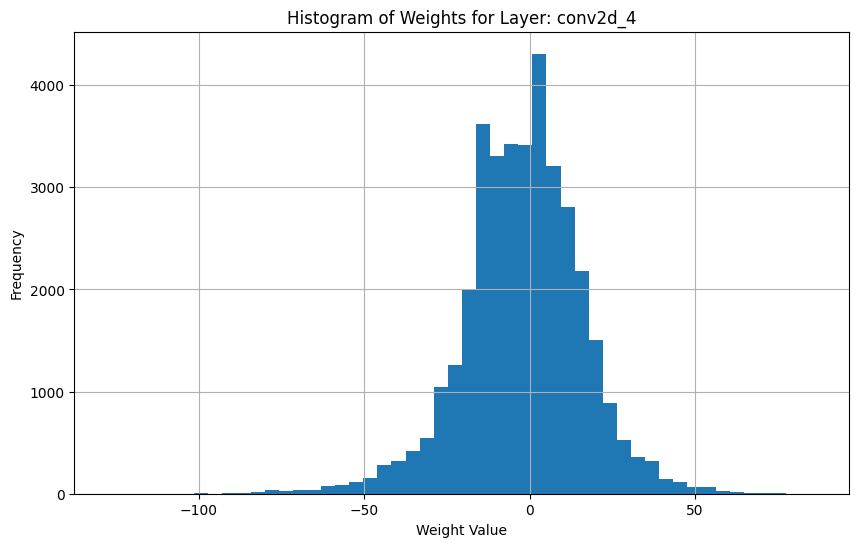

Max Weight: 0.5106551647186279
Min Weight: -0.5106551647186279
Weight Scale for conv2d_5: 248.70011854276902
Bias Scale for conv2d_5: 57177.16014598494
Quantized weights for conv2d_5, shape: (3, 3, 64, 128)
Quantized biases for conv2d_5, shape: (128,)


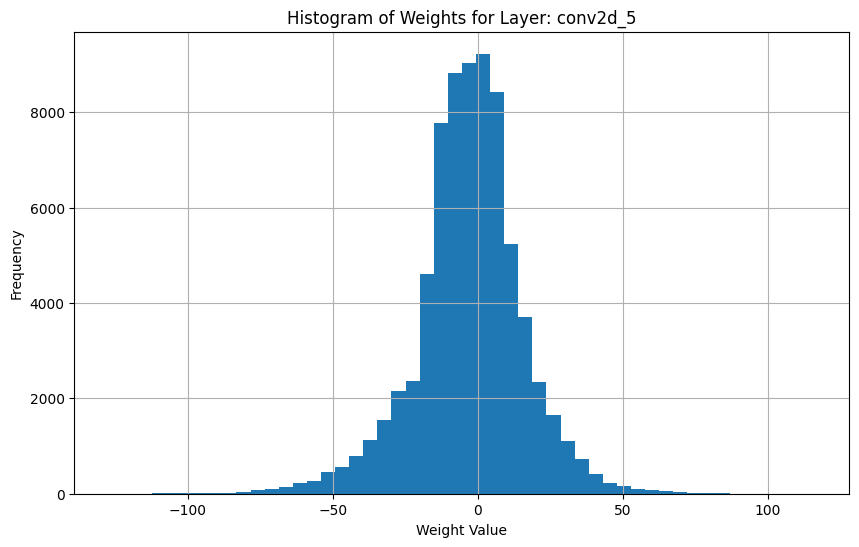

Max Weight: 0.5575851202011108
Min Weight: -0.5575851202011108
Weight Scale for dense: 227.76791452790815
Bias Scale for dense: 52364.76203303307
Quantized weights for dense, shape: (2048, 256)
Quantized biases for dense, shape: (256,)


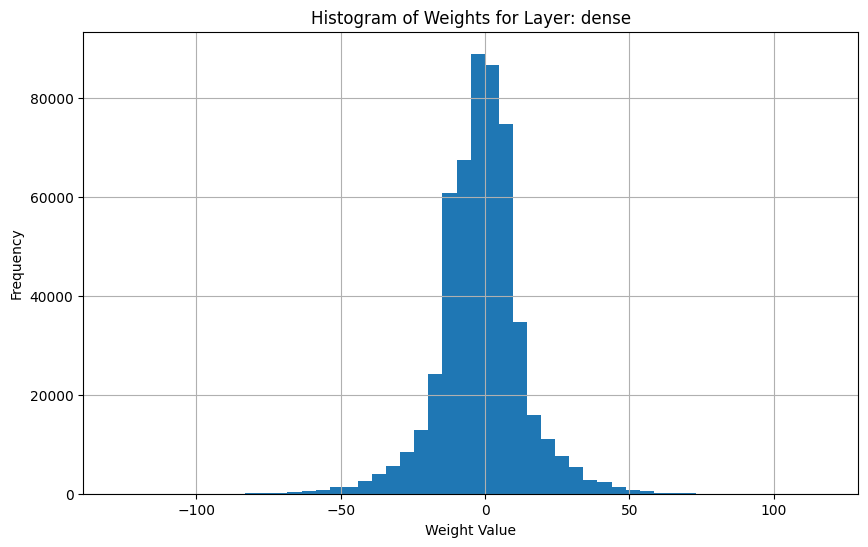

Max Weight: 1.3241188526153564
Min Weight: -1.3241188526153564
Weight Scale for dense_1: 95.91284026290671
Bias Scale for dense_1: 22050.748748740145
Quantized weights for dense_1, shape: (256, 200)
Quantized biases for dense_1, shape: (200,)


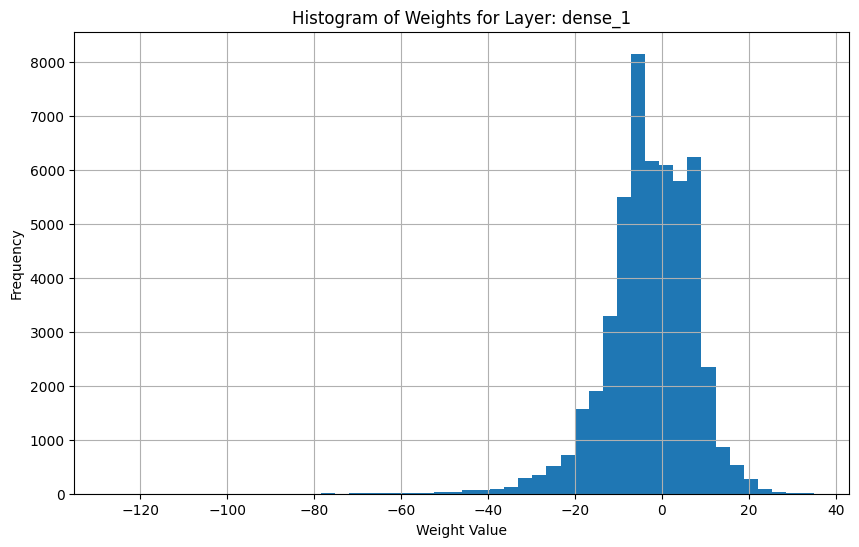

In [5]:
# First load model


model.summary()

# Create subdirectories
for subdir in ['quant_weights', 'image_activations']:
    subdir_path = os.path.join(img_dir, subdir)
    if not os.path.exists(subdir_path):
        Path(subdir_path).mkdir()

# Get weights for each convolutional layer using a helper function
def get_weight_scale(weights):
    flat_weights = np.concatenate([w.flatten() for w in weights])
    max_w = np.max(np.abs(flat_weights))
    min_w = np.min(flat_weights)
    print(f"Max Weight: {max_w}")
    print(f"Min Weight: {min_w}")
    if (max_w == 0):
        return 0.0
    scale = maxInt / max_w
    return scale

def get_bias_scale(biases):
    flat_biases = np.concatenate([b.flatten() for b in biases])
    max_b = np.max(np.abs(flat_biases))
    scale = maxInt / max_b
    return scale

def output_biases_to_bin(layer_name, quant_biases):
    with open(os.path.join(img_dir + "/quant_weights", f'{layer_name}_biases.bin'), 'wb') as bias_file:
        quant_biases.tofile(bias_file)

def output_weights_to_bin(layer_name, quant_weights):
    with open(os.path.join(img_dir + "/quant_weights", f'{layer_name}_weights.bin'), 'wb') as weight_file:
        quant_weights.tofile(weight_file)



# For each layer calculate quant weights and output to array
layers = [layer for layer in model.layers]
weights = [layer.get_weights()[0] for layer in layers if 'conv' in layer.name]

# For all layers, Im not sure if it per layer or overall so I have both just in case
overall_scale_weight = get_weight_scale(weights)
overall_scale_bias = overall_scale_weight * train_scale # Sb = Si * Sw
print(f"Overall Weight Scale: {overall_scale_weight}")
print(f"Overall Bias Scale: {overall_scale_bias}")



for layer in layers:
    if len(layer.get_weights()) > 0:
        scale_weight = get_weight_scale([layer.get_weights()[0]])
        scale_bias = scale_weight * train_scale # Sb = Si * Sw
        print(f"Weight Scale for {layer.name}: {scale_weight}")
        print(f"Bias Scale for {layer.name}: {scale_bias}")
        weights = layer.get_weights()[0]
        quant_weights = tf.cast(tf.round(weights * scale_weight), tf.int8)
        output_weights_to_bin(layer.name, quant_weights.numpy().flatten())
        print(f"Quantized weights for {layer.name}, shape: {quant_weights.shape}")

        if len(layer.get_weights()) > 1:  # Check for biases
            biases = layer.get_weights()[1]
            quant_biases = tf.cast(tf.round(biases * scale_bias), tf.int32)
            output_biases_to_bin(layer.name, quant_biases.numpy().flatten())
            print(f"Quantized biases for {layer.name}, shape: {quant_biases.shape}")

        quantized_weights_flat = quant_weights.numpy().flatten()
        layer_name = layer.name

        plt.figure(figsize=(10, 6))
        plt.hist(quantized_weights_flat, bins=50)
        plt.title(f'Histogram of Weights for Layer: {layer_name}')
        plt.xlabel('Weight Value')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()

In [6]:
# Choose a layer to test, for example, the first convolutional layer
layer_name_to_test = 'conv2d'
file_path_to_test = os.path.join(img_dir, "quant_weights", f'{layer_name_to_test}_weights.bin')

# Get the expected number of parameters from the model summary for that layer
# For 'conv2d', the shape is (5, 5, 3, 32), so params = 5 * 5 * 3 * 32 = 2400.
# The summary says 2,432 because it includes 32 biases. Weights are 2400.
# Let's get it programmatically to be sure.
layer_to_test = model.get_layer(layer_name_to_test)
expected_weight_count = np.prod(layer_to_test.get_weights()[0].shape)
print(f"Layer '{layer_name_to_test}' should have {expected_weight_count} weight values.")


# Try to read the binary file back
try:
    with open(file_path_to_test, 'rb') as f:
        # We saved as int8, so we must read as int8
        data_from_file = np.fromfile(f, dtype=np.int8)

    print(f"Successfully read the file: {file_path_to_test}")
    print(f"Number of elements read: {data_from_file.size}")

    # Critical Check: Does the size match?
    if data_from_file.size == expected_weight_count:
        print("✅ Success: The number of elements read matches the expected count.")
    else:
        print("❌ Error: Mismatch in the number of elements!")
        print(f"Expected {expected_weight_count}, but read {data_from_file.size}.")

except FileNotFoundError:
    print(f"❌ Error: The file was not found at {file_path_to_test}. Make sure the directory exists and the script ran.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Layer 'conv2d' should have 2400 weight values.
Successfully read the file: /home/tbibus/CprE587/CPRE-4870/Lab 3/lab6_template/img_data/quant_weights/conv2d_weights.bin
Number of elements read: 2400
✅ Success: The number of elements read matches the expected count.


In [7]:
# # --- 1. Load the model and data ---
# model_path = os.path.abspath("CNN_TinyImageNet.h5")
# if not os.path.exists(model_path):
#     raise FileNotFoundError(f"Model file not found at: {model_path}")

# print("Loading model...")
# model = tf.keras.models.load_model(model_path)
# print("Model loaded successfully.")

# # You can print the model object itself to see its type
# print(f"Loaded model type: {type(model)}")

# # Load your validation images here
# # val_imgs = load_calibration_dataset_from_bin(...)
# # Using dummy data for this example
# val_imgs = [np.random.rand(1, 64, 64, 3).astype(np.float32) for _ in range(100)]

# # --- 2. Define model properties ---
# # IMPORTANT: You must know the input shape the model was trained with.
# # For Tiny ImageNet, this is typically (64, 64, 3).
# INPUT_SHAPE = (64, 64, 3)

# # IMPORTANT: Print the summary to find the *actual* layer names.
# # To do this, we must first build the model.
# if not model.built:
#     model.build(input_shape=(None,) + INPUT_SHAPE)
# model.summary()

# # Now, choose the real name from the summary output.
# layer_name_to_capture = 'conv2d' # <--- CHANGE THIS to a real layer name from the summary

# # --- 3. The Robust Method: Rebuild the model path functionally ---

# print(f"\nBuilding a new activation model for layer: '{layer_name_to_capture}'")

# try:
#     # Find the layer object from the loaded model
#     target_layer = model.get_layer(name=layer_name_to_capture)
# except ValueError as e:
#     print(f"\nFATAL ERROR: {e}")
#     print("Please check the 'Layer (type)' column in the summary above and update the 'layer_name_to_capture' variable.")
#     exit()

# # Step 3.1: Create a new, standalone input tensor. This replaces `model.input`.
# new_input = tf.keras.Input(shape=INPUT_SHAPE, name="new_input_tensor")

# # Step 3.2: Manually pass the tensor through each layer of the loaded model
# # until we reach our target layer.
# x = new_input
# for layer in model.layers:
#     x = layer(x)
#     if layer.name == target_layer.name:
#         # We've reached our target layer. The current `x` is its output.
#         break

# # Step 3.3: Create the final activation model.
# # Its input is our new input tensor, and its output is the output of the target layer.
# activation_model = tf.keras.Model(inputs=new_input, outputs=x)
# print("Activation model created successfully.")
# activation_model.summary()


# # --- 4. Run Calibration (This part remains the same) ---
# print(f"\nRunning calibration...")
# min_val = float('inf')
# max_val = float('-inf')

# for i, image_input in enumerate(val_imgs):
#     activations = activation_model.predict(image_input, verbose=0)
#     current_min = np.min(activations)
#     current_max = np.max(activations)

#     if current_min < min_val:
#         min_val = current_min
#     if current_max > max_val:
#         max_val = current_max
#     if (i+1) % 100 == 0:
#         print(f"  ...processed {i+1}/{len(val_imgs)} images")

# print("\nCalibration complete!")
# print(f"Overall Min activation value for '{layer_name_to_capture}': {min_val}")
# print(f"Overall Max activation value for '{layer_name_to_capture}': {max_val}")

# scale = (max_val - min_val) / (255)
# zero_point = round(127 - (max_val / scale))

# print(f"Output Scale Value for '{layer_name_to_capture}': {min_val}")
# print(f"Output Zero Scale Value for '{layer_name_to_capture}': {max_val}")




In [8]:
# # --- 1. Load the Model and Prepare Data ---

# # Define the path to your trained model file
# model_path = os.path.abspath("CNN_TinyImageNet.h5")

# if not os.path.exists(model_path):
#     raise FileNotFoundError(f"FATAL ERROR: Model file not found at: {model_path}")

# print("Loading model...")
# model = tf.keras.models.load_model(model_path)
# print("Model loaded successfully.")
# print("-" * 50)

# # Load your calibration dataset (the 1,000 random validation images, normalized to [0,1])
# print("Loading calibration data...")
# num_calibration_images = 1000
# val_imgs = [img_data['image'].numpy() / 255.0 for img_data in val_data]  # Normalize if uint8
# print(f"{len(val_imgs)} images loaded.")
# print("-" * 50)


# # --- 2. Define Model Properties and Get Layer Names ---

# INPUT_SHAPE = (64, 64, 3)

# print("Model Summary:")
# model.summary()
# print("-" * 50)

# # Get the names of all convolutional and dense layers to analyze
# layers_to_capture = [
#     layer.name for layer in model.layers
#     if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense))
# ]

# if not layers_to_capture:
#     raise ValueError("FATAL ERROR: Could not find any Conv2D or Dense layers in the model.")

# print(f"Found {len(layers_to_capture)} layers to analyze: {layers_to_capture}")
# print("-" * 50)


# # --- 3. Build the Activation Model using the ROBUST Functional Method ---

# print("Building a functional model to capture all intermediate activations...")

# # Create a new, explicit input tensor. This replaces the problematic `model.input`.
# new_input = tf.keras.Input(shape=INPUT_SHAPE)

# # Use a dictionary to map layer names to their output tensors
# layer_outputs = {}
# # Start the graph with our new input
# x = new_input

# # Loop through each layer of the loaded model
# for layer in model.layers:
#     # Connect the layer to the output of the previous one
#     x = layer(x)
#     # If this is a layer we want to capture, save its output tensor
#     if layer.name in layers_to_capture:
#         layer_outputs[layer.name] = x

# # The outputs of our new model are the tensors we collected, in the correct order
# # This ensures the output list matches the `layers_to_capture` list order
# ordered_outputs = [layer_outputs[name] for name in layers_to_capture]

# # Create the final activation model
# activation_model = tf.keras.Model(inputs=new_input, outputs=ordered_outputs)

# print("Activation model created successfully.")
# activation_model.summary() # Optional: view the new model's structure
# print("-" * 50)


# # --- 4. Run Calibration Efficiently with Batch Processing ---

# print("Running calibration...")
# calibration_data_batch = np.array(val_imgs)  # Shape: (1000, 64, 64, 3)
# print(f"Created calibration batch with shape: {calibration_data_batch.shape}")

# all_activations = activation_model.predict(calibration_data_batch)

# print("Calibration prediction complete.")
# print("-" * 50)


# # --- 5. Calculate and Print Quantization Parameters for Each Layer ---

# print("Calculating Quantization Parameters for each layer:")

# # Initial input params (for images [0,1] -> asymmetric INT8 [-128,127])
# prev_output_scale, prev_output_zp = (1.0 / 255.0), -128

# # Dict to store params
# quant_params = {}

# # Create model dir for .bin files
# model_dir = os.path.abspath('model')
# pathlib.Path(model_dir).mkdir(exist_ok=True)

# for i, layer_name in enumerate(layers_to_capture):
#     # Get weights and biases
#     layer = model.get_layer(layer_name)
#     weights, biases = layer.get_weights()
    
#     # Weights: symmetric INT8 (zero_point=0)
#     w_min, w_max = np.min(weights), np.max(weights)
#     w_abs_max = max(abs(w_min), abs(w_max))
#     w_scale = w_abs_max / 127.0 if w_abs_max != 0 else 1.0
#     w_zp = 0
#     weights_q = np.clip(np.round(weights / w_scale + w_zp), -128, 127).astype(np.int8)
#     weights_q.tofile(os.path.join(model_dir, f"{layer_name}_weights.bin"))
    
#     # Biases: INT32, scaled by input_scale * weight_scale
#     input_scale = prev_output_scale
#     input_zp = prev_output_zp
#     bias_scale = input_scale * w_scale
#     biases_q = np.round(biases / bias_scale).astype(np.int32)
#     biases_q.tofile(os.path.join(model_dir, f"{layer_name}_biases.bin"))
    
#     # Outputs (activations): asymmetric INT8
#     layer_acts = all_activations[i]
#     min_val, max_val = np.min(layer_acts), np.max(layer_acts)
#     if min_val == max_val:
#         o_scale, o_zp = 1.0, 0
#     else:
#         o_scale = (max_val - min_val) / 255.0
#         o_zp = np.round(-min_val / o_scale - 128)
#         o_zp = np.clip(o_zp, -128, 127)
    
#     quant_params[layer_name] = {
#         'input_scale': input_scale, 'input_zp': input_zp,
#         'weight_scale': w_scale, 'weight_zp': w_zp,
#         'bias_scale': bias_scale,
#         'output_scale': o_scale, 'output_zp': o_zp
#     }
    
#     # Print
#     print(f"\n> Layer: '{layer_name}'")
#     print(f"  - Input scale:    {input_scale:.6f}, zero_point: {input_zp}")
#     print(f"  - Weights scale:  {w_scale:.6f}, zero_point: {w_zp}")
#     print(f"  - Bias scale:     {bias_scale:.6f}")
#     print(f"  - Output scale:   {o_scale:.6f}, zero_point: {o_zp}")
    
#     # Update for next layer
#     prev_output_scale, prev_output_zp = o_scale, o_zp

# # Save params to file for C++ use
# with open(os.path.abspath('quant_params.txt'), 'w') as f:
#     for layer_name, params in quant_params.items():
#         f.write(f"Layer: {layer_name}\n")
#         for k, v in params.items():
#             f.write(f"  {k}: {v}\n")
#         f.write("\n")

# print("\nScript finished.")